<style>
.reveal { font-family: 'Segoe UI', system-ui, sans-serif; font-size: 1.05em; }
.reveal h2 { color: #0D2240; border-bottom: 2.5px solid #1A7A9A; padding-bottom: .3em; }
.reveal h3 { color: #1A7A9A; }
.reveal .slides section { text-align: left; }
.reveal pre { font-size: .75em; box-shadow: none; border-left: 3px solid #1A7A9A; }
.defn { background:#EAF6FA; border-left:4px solid #1A7A9A; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
.nota { background:#FFF8E1; border-left:4px solid #C8961E; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
.alerta { background:#FDE8E8; border-left:4px solid #C0392B; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
</style>

## Análisis de Salida: Simulaciones Terminales
### T3.3 · Modelado de Sistemas bajo Incertidumbre
Universidad de los Andes · Ingeniería Industrial

## Agenda
1. Terminal vs. estacionaria — ¿por qué importa?
2. Autocorrelación: por qué S/√m no funciona dentro de una corrida
3. Método de réplicas independientes
4. **Ejemplo 1:** banco M/M/1 terminal — 10 réplicas, IC al 95%
5. Determinación de n* (procedimiento secuencial)
6. **Ejemplo 2:** banco M/E₂/1 — cálculo de n* y comparación pareada con M/M/1
7. **Ejemplo 3:** urgencias hospitalarias — selección entre 3 vs 4 médicos

## Terminal vs. estacionaria
<div class='defn'>
<strong>Terminal:</strong> horizonte finito con evento de cierre natural. Las condiciones iniciales son parte del modelo.<br>
<strong>Estacionaria:</strong> comportamiento de largo plazo, independiente de condiciones iniciales.
</div>

| | Terminal | Estacionaria |
|---|---|---|
| **Ejemplos** | Turno de banco, jornada de urgencias | Fábrica 24/7, call center |
| **Inicio** | Estado fijo (p.ej. vacío) | Arbitrario (warm-up) |
| **Método** | Réplicas independientes | Batch Means (T3.4) |

<div class='alerta'>
⚠️ Usar el método equivocado produce conclusiones inválidas. Un turno de banco no se puede analizar como estado estacionario.
</div>

## ¿Por qué S/√m no funciona dentro de una corrida?

Las observaciones Y₁, Y₂, ... están **autocorrelacionadas**:

$$\text{Var}[\bar{Y}_m] = \frac{\sigma^2}{m}\left[1 + 2\sum_{k=1}^{m-1}\left(1-\frac{k}{m}\right)\rho(k)\right]$$

Con autocorrelación positiva (típica en colas): **Var[Ȳ] >> σ²/m**

<div class='alerta'>
Si usas S/√m dentro de una sola corrida, la cobertura real del IC al "95%" puede caer al <strong>50–70%</strong>.
</div>

**Solución:** réplicas independientes → cada réplica produce un solo Y_j → los Y_j sí son i.i.d.

## Ejemplo 1 — Banco M/M/1 terminal (4 horas)
<div class='defn'>
Ventanilla bancaria: turno de 9:00 a 13:00 (240 min).
λ=2 cl/min, μ=3 cl/min, ρ=0.667. Sistema inicia vacío.
Estimar W_q con IC al 95%.
</div>

**Referencia analítica** (estacionario, sólo para comparar):
$$W_q^{M/M/1} = \frac{\rho}{\mu(1-\rho)} = \frac{0.667}{3 \times 0.333} = 0.667 \text{ min}$$

*La simulación terminal incluye el transitorio, así que Ȳ será ligeramente menor que 0.667.*

In [1]:
import simpy
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

def simular_turno_mm1(lam, mu, T, seed):
    """Simula un turno terminal M/M/1. Retorna (Wq promedio, # clientes)."""
    np.random.seed(seed)
    esperas = []

    def cliente(env, srv):
        t_arr = env.now
        with srv.request() as req:
            yield req
            esperas.append(env.now - t_arr)
            yield env.timeout(np.random.exponential(1/mu))

    def llegadas(env, srv):
        while True:
            yield env.timeout(np.random.exponential(1/lam))
            env.process(cliente(env, srv))

    env = simpy.Environment()
    srv = simpy.Resource(env, capacity=1)
    env.process(llegadas(env, srv))
    env.run(until=T)
    return (np.mean(esperas) if esperas else 0.0), len(esperas), esperas

print('Función simular_turno_mm1 definida.')

Función simular_turno_mm1 definida.


In [2]:
lam, mu = 2, 3
T_turno = 240
Wq_ref = (lam/mu) / (mu * (1-lam/mu))

n = 10
Y = np.zeros(n)
m_clientes = np.zeros(n, dtype=int)
for j in range(n):
    Y[j], m_clientes[j], _ = simular_turno_mm1(lam, mu, T_turno, seed=100+j)

print(f'═══ 10 RÉPLICAS DEL TURNO M/M/1 ═══')
print(f'{"j":>3} {"Yj (min)":>10} {"# clientes":>12}')
print('-'*28)
for j in range(n):
    print(f'{j+1:>3} {Y[j]:>10.3f} {m_clientes[j]:>12}')

═══ 10 RÉPLICAS DEL TURNO M/M/1 ═══
  j   Yj (min)   # clientes
----------------------------
  1      0.656          467
  2      0.485          464
  3      0.514          470
  4      0.709          485
  5      0.863          498
  6      0.677          443
  7      0.504          479
  8      0.487          455
  9      0.517          487
 10      0.545          443


In [3]:
Ybar = Y.mean()
S_n = Y.std(ddof=1)
t_crit = st.t.ppf(0.975, n-1)
h_n = t_crit * S_n / np.sqrt(n)
ci = (Ybar - h_n, Ybar + h_n)
r_n = h_n / abs(Ybar)

print('═══ INTERVALO DE CONFIANZA AL 95% ═══')
print(f'Ȳ              = {Ybar:.3f} min')
print(f'S              = {S_n:.3f} min')
print(f't(0.025, {n-1})    = {t_crit:.3f}')
print(f'Semiancho h    = {h_n:.3f} min')
print(f'IC 95%         = [{ci[0]:.3f}, {ci[1]:.3f}] min')
print(f'Precisión rel. = {r_n:.1%}')
print(f'\nRef. estacionaria Wq = {Wq_ref:.3f} min')
print(f'¿IC contiene la referencia? {"Sí ✓" if ci[0] <= Wq_ref <= ci[1] else "No"}')

═══ INTERVALO DE CONFIANZA AL 95% ═══
Ȳ              = 0.596 min
S              = 0.126 min
t(0.025, 9)    = 2.262
Semiancho h    = 0.090 min
IC 95%         = [0.506, 0.686] min
Precisión rel. = 15.1%

Ref. estacionaria Wq = 0.667 min
¿IC contiene la referencia? Sí ✓


In [4]:
# Demostración: dentro de UNA corrida las esperas están autocorrelacionadas
_, _, esperas_una_corrida = simular_turno_mm1(lam, mu, T_turno, seed=42)
W = np.array(esperas_una_corrida)

def autocorr(x, maxlag=30):
    x_c = x - x.mean()
    r = np.correlate(x_c, x_c, 'full')
    r = r[len(r)//2:] / r[len(r)//2]
    return r[:maxlag+1]

rho_k = autocorr(W, 30)
print(f'Cliente más alto en la corrida: {len(W)}')
print(f'ρ(1) = {rho_k[1]:.3f}   ρ(5) = {rho_k[5]:.3f}   ρ(10) = {rho_k[10]:.3f}')
print('Hay autocorrelación significativa: usar S/√m subestimaría el error estándar.')

Cliente más alto en la corrida: 488
ρ(1) = 0.830   ρ(5) = 0.425   ρ(10) = 0.147
Hay autocorrelación significativa: usar S/√m subestimaría el error estándar.


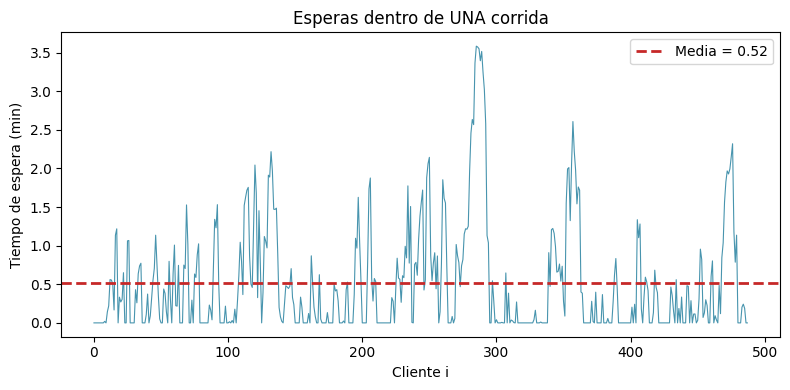

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(W, color='#1A7A9A', lw=0.8, alpha=0.8)
ax.axhline(W.mean(), color='#C62828', lw=2, ls='--', label=f'Media = {W.mean():.2f}')
ax.set_xlabel('Cliente i'); ax.set_ylabel('Tiempo de espera (min)')
ax.set_title('Esperas dentro de UNA corrida')
ax.legend()
plt.tight_layout(); plt.show()

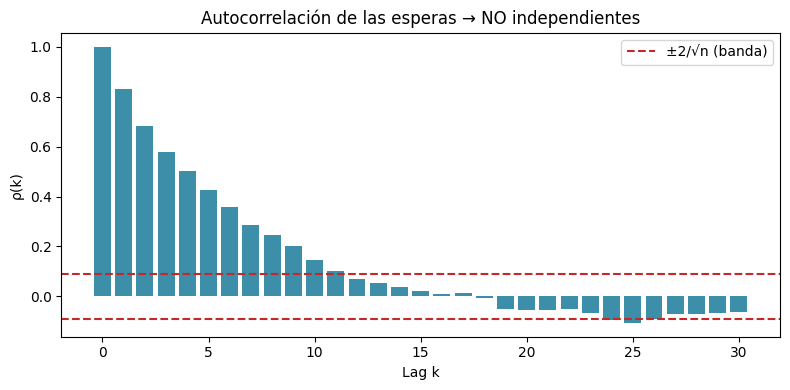

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(rho_k)), rho_k, color='#1A7A9A', alpha=0.85)
ax.axhline(2/np.sqrt(len(W)), ls='--', color='#C62828', label='±2/√n (banda)')
ax.axhline(-2/np.sqrt(len(W)), ls='--', color='#C62828')
ax.set_xlabel('Lag k'); ax.set_ylabel('ρ(k)')
ax.set_title('Autocorrelación de las esperas → NO independientes')
ax.legend()
plt.tight_layout(); plt.show()

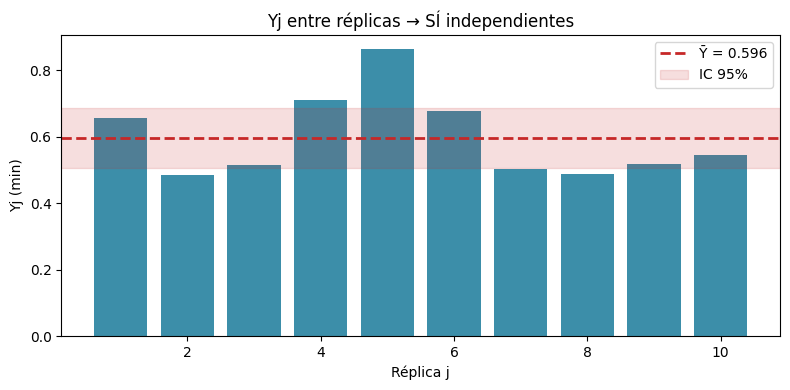

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, n+1), Y, color='#1A7A9A', alpha=0.85)
ax.axhline(Ybar, color='#C62828', lw=2, ls='--', label=f'Ȳ = {Ybar:.3f}')
ax.axhspan(ci[0], ci[1], alpha=0.15, color='#C62828', label='IC 95%')
ax.set_xlabel('Réplica j'); ax.set_ylabel('Yj (min)')
ax.set_title('Yj entre réplicas → SÍ independientes')
ax.legend()
plt.tight_layout(); plt.show()

## Ejemplo 2 — Banco M/E₂/1 con n* y comparación pareada
<div class='defn'>
Mismo banco pero con servicio Erlang-2 (CV=0.71). Queremos:
1. Estimar Wq con precisión δ=0.05 min al 95%
2. Comparar formalmente M/M/1 vs M/E₂/1 con prueba pareada (CRN: misma semilla por réplica)
</div>

**Procedimiento secuencial para n*:**
1. Piloto de n₀ ≥ 10 réplicas → S²
2. n* = ⌈t²·S² / δ²⌉
3. Si n* > n₀ ejecutar las restantes, recalcular IC

In [8]:
def simular_turno_me2(lam, mu_fase, T, seed):
    """Simula turno terminal M/E₂/1. Retorna (Wq promedio, # clientes)."""
    np.random.seed(seed)
    esperas = []

    def cliente(env, srv):
        t_arr = env.now
        with srv.request() as req:
            yield req
            esperas.append(env.now - t_arr)
            yield env.timeout(np.random.exponential(1/mu_fase))
            yield env.timeout(np.random.exponential(1/mu_fase))

    def llegadas(env, srv):
        while True:
            yield env.timeout(np.random.exponential(1/lam))
            env.process(cliente(env, srv))

    env = simpy.Environment()
    srv = simpy.Resource(env, capacity=1)
    env.process(llegadas(env, srv))
    env.run(until=T)
    return (np.mean(esperas) if esperas else 0.0), len(esperas)

print('Función simular_turno_me2 definida.')

Función simular_turno_me2 definida.


In [9]:
mu_fase_e2 = 2 * mu  # mu_fase=6 → E[S]=2/6=1/3 min, ρ=2/3
delta = 0.05

n0 = 15
Y_pilot = np.array([simular_turno_me2(lam, mu_fase_e2, T_turno, seed=500+j)[0]
                    for j in range(n0)])

Ybar_p = Y_pilot.mean()
S_p = Y_pilot.std(ddof=1)
t_p = st.t.ppf(0.975, n0-1)
h_p = t_p * S_p / np.sqrt(n0)

print('═══ PILOTO M/E₂/1 (n₀=15) ═══')
print(f'Ȳ = {Ybar_p:.3f} min')
print(f'S = {S_p:.4f} min')
print(f'h = {h_p:.4f} min   (objetivo δ = {delta:.2f})')

═══ PILOTO M/E₂/1 (n₀=15) ═══
Ȳ = 0.524 min
S = 0.1420 min
h = 0.0787 min   (objetivo δ = 0.05)


In [10]:
n_star = int(np.ceil((t_p**2 * S_p**2) / delta**2))
print(f'n* = ⌈({t_p:.3f}² × {S_p:.4f}²) / {delta}²⌉ = {n_star}')

if n_star <= n0:
    print(f'n* ≤ n₀ → el piloto basta')
    Y_me2 = Y_pilot
else:
    print(f'n* > n₀ → ejecutar {n_star - n0} réplicas adicionales')
    Y_extra = np.array([simular_turno_me2(lam, mu_fase_e2, T_turno, seed=600+j)[0]
                        for j in range(n_star - n0)])
    Y_me2 = np.concatenate([Y_pilot, Y_extra])

n_final = len(Y_me2)
mean_me2 = Y_me2.mean()
S_me2 = Y_me2.std(ddof=1)
h_me2 = st.t.ppf(0.975, n_final-1) * S_me2 / np.sqrt(n_final)

print(f'\nResultado final con n={n_final}:')
print(f'  Ȳ = {mean_me2:.3f}, h = {h_me2:.4f} {"✓" if h_me2 <= delta else "→ repetir con n mayor"}')
print(f'  IC 95% = [{mean_me2-h_me2:.3f}, {mean_me2+h_me2:.3f}]')

# Referencia P-K
ES_e2 = 1/mu
ES2_e2 = 2/mu_fase_e2**2 + ES_e2**2
rho_e2 = lam * ES_e2
Wq_PK_e2 = lam * ES2_e2 / (2*(1-rho_e2))
print(f'\nRef. P-K (estacionaria): Wq = {Wq_PK_e2:.3f} min')

n* = ⌈(2.145² × 0.1420²) / 0.05²⌉ = 38
n* > n₀ → ejecutar 23 réplicas adicionales

Resultado final con n=38:
  Ȳ = 0.503, h = 0.0478 ✓
  IC 95% = [0.455, 0.550]

Ref. P-K (estacionaria): Wq = 0.500 min


In [11]:
# Comparación pareada: misma semilla en M/M/1 y M/E₂/1
n_comp = max(n_final, 30)
seeds = np.arange(700, 700+n_comp)

Y_mm1_p = np.array([simular_turno_mm1(lam, mu, T_turno, s)[0] for s in seeds])
Y_me2_p = np.array([simular_turno_me2(lam, mu_fase_e2, T_turno, s)[0] for s in seeds])

D = Y_mm1_p - Y_me2_p
n_d = len(D)
mean_D = D.mean()
S_D = D.std(ddof=1)
t_cD = st.t.ppf(0.975, n_d-1)
h_D = t_cD * S_D / np.sqrt(n_d)
T_D = mean_D / (S_D/np.sqrt(n_d))
p_D = 2 * (1 - st.t.cdf(abs(T_D), n_d-1))
d_cohen = mean_D / Y_mm1_p.std(ddof=1)

print(f'═══ COMPARACIÓN PAREADA M/M/1 vs M/E₂/1 (n={n_d}) ═══')
print(f'\n{"Sistema":<10} {"Ȳ (min)":>10} {"S (min)":>10} {"IC 95%":>22}')
print('-'*55)
print(f'{"M/M/1":<10} {Y_mm1_p.mean():>10.3f} {Y_mm1_p.std(ddof=1):>10.3f}    [{Ybar-h_n:.3f}, {Ybar+h_n:.3f}]')
print(f'{"M/E₂/1":<10} {Y_me2_p.mean():>10.3f} {Y_me2_p.std(ddof=1):>10.3f}    [{mean_me2-h_me2:.3f}, {mean_me2+h_me2:.3f}]')

print(f'\n--- Diferencias pareadas D = Wq(M/M/1) − Wq(M/E₂/1) ---')
print(f'D̄ = {mean_D:.4f} min,  S_D = {S_D:.4f}')
print(f'IC 95%(D) = [{mean_D-h_D:.4f}, {mean_D+h_D:.4f}]')
print(f'¿IC excluye 0? {"Sí → diferencia significativa" if (mean_D-h_D > 0 or mean_D+h_D < 0) else "No"}')
print(f'Prueba t pareada:  T = {T_D:+.3f},  p-valor = {p_D:.3e}')
print(f'Tamaño de efecto d Cohen ≈ {d_cohen:.2f}')

if p_D < 0.05:
    ganador = 'M/E₂/1' if mean_D > 0 else 'M/M/1'
    print(f'\n⇒ El servicio Erlang-2 reduce la espera en ~{abs(mean_D):.3f} min ({abs(mean_D)/Y_mm1_p.mean()*100:.0f}%).')
    print(f'   Recomendación: preferir {ganador}.')
else:
    print('\n⇒ Las dos alternativas no se diferencian estadísticamente.')

═══ COMPARACIÓN PAREADA M/M/1 vs M/E₂/1 (n=38) ═══

Sistema       Ȳ (min)    S (min)                 IC 95%
-------------------------------------------------------
M/M/1           0.618      0.151    [0.506, 0.686]
M/E₂/1          0.501      0.148    [0.455, 0.550]

--- Diferencias pareadas D = Wq(M/M/1) − Wq(M/E₂/1) ---
D̄ = 0.1169 min,  S_D = 0.1716
IC 95%(D) = [0.0605, 0.1733]
¿IC excluye 0? Sí → diferencia significativa
Prueba t pareada:  T = +4.200,  p-valor = 1.613e-04
Tamaño de efecto d Cohen ≈ 0.77

⇒ El servicio Erlang-2 reduce la espera en ~0.117 min (19%).
   Recomendación: preferir M/E₂/1.


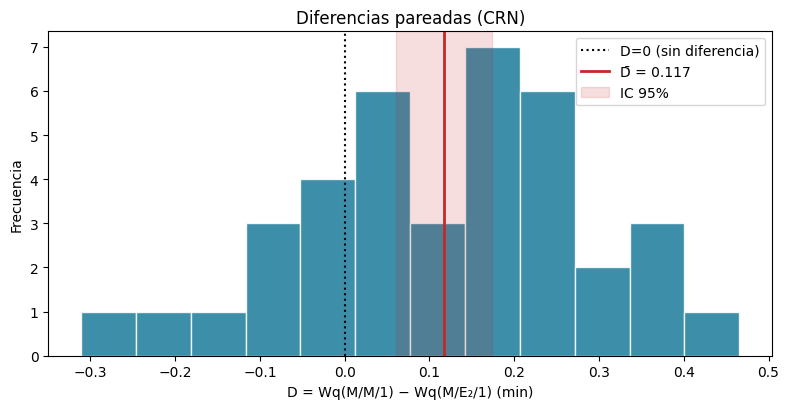

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(D, bins=12, color='#1A7A9A', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=1.5, ls=':', label='D=0 (sin diferencia)')
ax.axvline(mean_D, color='#C62828', lw=2, label=f'D̄ = {mean_D:.3f}')
ax.axvspan(mean_D-h_D, mean_D+h_D, alpha=0.15, color='#C62828', label='IC 95%')
ax.set_xlabel('D = Wq(M/M/1) − Wq(M/E₂/1) (min)'); ax.set_ylabel('Frecuencia')
ax.set_title('Diferencias pareadas (CRN)')
ax.legend()
plt.tight_layout(); plt.show()

## Ejemplo 3 — Urgencias hospitalarias: ¿3 o 4 médicos?
<div class='defn'>
Turno 7:00–15:00 (8 h). Llegadas λ=5 pac/h con 3 prioridades. Cola con prioridad no expulsiva.

| Nivel | Fracción | Servicio | E[S] | CV |
|---|---|---|---|---|
| P1 (urgente)  | 15% | Exp(μ=0.1)              | 10 min | 1.00 |
| P2 (moderado) | 55% | Erlang-3(μf=0.1)        | 30 min | 0.58 |
| P3 (leve)     | 30% | LogNormal(μL=3.4, σL=0.5) | 35 min | 0.53 |

E[S] global ≈ 28.5 min/paciente → carga ofrecida λ·E[S] ≈ 2.38 médicos.
Con c=3 → ρ≈0.79 (carga alta);  con c=4 → ρ≈0.59 (carga moderada).
</div>

**Decisión a tomar:** ¿la configuración base (c=3 médicos) ofrece servicio aceptable, o conviene contratar un médico adicional (c=4)?
**Métricas:** Wq(P2), P(Wq>30 min | P3) y utilización ρ. **No existe solución analítica → simulación.**

In [13]:
def urgencias(lam, T, c, seed):
    """Urgencias con prioridades no expulsivas. Retorna (Wq_P2, P(Wq>30|P3), rho)."""
    np.random.seed(seed)
    esperas = {1: [], 2: [], 3: []}
    tiempos_ocup = []

    def gen_servicio(prio):
        if prio == 1:
            return np.random.exponential(10)
        elif prio == 2:
            return sum(np.random.exponential(10) for _ in range(3))
        else:
            return np.random.lognormal(3.4, 0.5)

    def paciente(env, srv, prio):
        t_arr = env.now
        with srv.request(priority=prio) as req:
            yield req
            esperas[prio].append(env.now - t_arr)
            t_srv = gen_servicio(prio)
            tiempos_ocup.append(t_srv)
            yield env.timeout(t_srv)

    def llegadas(env, srv):
        while True:
            yield env.timeout(np.random.exponential(60/lam))
            u = np.random.random()
            prio = 1 if u < 0.15 else (2 if u < 0.70 else 3)
            env.process(paciente(env, srv, prio))

    env = simpy.Environment()
    srv = simpy.PriorityResource(env, capacity=c)
    env.process(llegadas(env, srv))
    env.run(until=T)

    Wq_P2 = float(np.mean(esperas[2])) if esperas[2] else 0.0
    prob_P3 = float(np.mean([w > 30 for w in esperas[3]])) if esperas[3] else 0.0
    rho = sum(tiempos_ocup) / (T * c)
    return Wq_P2, prob_P3, rho

print('Función urgencias definida.')

Función urgencias definida.


In [14]:
T_urg = 480
lam_urg = 5
n0_u = 15

# Piloto con configuración base c=3
res_pilot_3 = np.array([urgencias(lam_urg, T_urg, c=3, seed=800+j) for j in range(n0_u)])

print('═══ PILOTO c=3 médicos (n₀=15) ═══')
metricas = ['Wq(P2) min', 'P(Wq>30|P3)', 'ρ']
for i, name in enumerate(metricas):
    data = res_pilot_3[:, i]
    m, s = data.mean(), data.std(ddof=1)
    h = st.t.ppf(0.975, n0_u-1) * s / np.sqrt(n0_u)
    r = h/abs(m) if m != 0 else float('inf')
    print(f'  {name:<14}: Ȳ={m:7.3f}  S={s:6.3f}  r={r:5.1%}')

m, s = res_pilot_3[:,0].mean(), res_pilot_3[:,0].std(ddof=1)
n_star = int(np.ceil((st.t.ppf(0.975, n0_u-1)**2 * s**2) / (0.05*m)**2))
n_max = 200
n_final = min(max(n_star, n0_u, 30), n_max)
print(f'\nn* (objetivo r ≤ 5% para Wq(P2)) = {n_star}')
print(f'Cap pedagógico:  ejecutaremos n = {n_final}  (suficiente para detectar diferencias)')

═══ PILOTO c=3 médicos (n₀=15) ═══
  Wq(P2) min    : Ȳ=  4.596  S= 3.771  r=45.4%
  P(Wq>30|P3)   : Ȳ=  0.164  S= 0.174  r=58.7%
  ρ             : Ȳ=  0.721  S= 0.103  r= 7.9%

n* (objetivo r ≤ 5% para Wq(P2)) = 1239
Cap pedagógico:  ejecutaremos n = 200  (suficiente para detectar diferencias)


In [15]:
# CRN: misma semilla por réplica para ambas configuraciones
seeds_u = np.arange(900, 900 + n_final)
res_3 = np.array([urgencias(lam_urg, T_urg, c=3, seed=int(s)) for s in seeds_u])
res_4 = np.array([urgencias(lam_urg, T_urg, c=4, seed=int(s)) for s in seeds_u])

print(f'═══ ESTIMACIONES POR ALTERNATIVA (n={n_final}, CRN) ═══')
print(f'{"Métrica":<14} {"c=3 Ȳ ± h":>20} {"c=4 Ȳ ± h":>20}')
print('-'*56)
for i, name in enumerate(metricas):
    m3, s3 = res_3[:,i].mean(), res_3[:,i].std(ddof=1)
    h3 = st.t.ppf(0.975, n_final-1) * s3/np.sqrt(n_final)
    m4, s4 = res_4[:,i].mean(), res_4[:,i].std(ddof=1)
    h4 = st.t.ppf(0.975, n_final-1) * s4/np.sqrt(n_final)
    print(f'{name:<14} {m3:>10.3f} ± {h3:<7.3f} {m4:>10.3f} ± {h4:<7.3f}')

═══ ESTIMACIONES POR ALTERNATIVA (n=200, CRN) ═══
Métrica                   c=3 Ȳ ± h            c=4 Ȳ ± h
--------------------------------------------------------
Wq(P2) min          6.542 ± 0.745        2.187 ± 0.353  
P(Wq>30|P3)         0.178 ± 0.028        0.038 ± 0.013  
ρ                   0.749 ± 0.018        0.581 ± 0.016  


In [16]:
print('═══ COMPARACIÓN PAREADA c=3 vs c=4 (CRN) ═══\n')
t_cN = st.t.ppf(0.975, n_final-1)
print(f'{"Métrica":<14} {"D̄":>9} {"IC 95%(D)":>22} {"p":>10} {"Decisión":>12}')
print('-'*70)

resultados = []
for i, name in enumerate(metricas):
    D = res_3[:, i] - res_4[:, i]
    mD, sD = D.mean(), D.std(ddof=1)
    hD = t_cN * sD / np.sqrt(n_final)
    T = mD / (sD/np.sqrt(n_final)) if sD > 0 else float('inf')
    p = 2*(1 - st.t.cdf(abs(T), n_final-1)) if sD > 0 else 0.0
    sig = p < 0.05
    resultados.append({'nombre': name, 'mD': mD, 'hD': hD, 'p': p, 'sig': sig})
    decision = 'sig. ✓' if sig else 'NS'
    print(f'{name:<14} {mD:>9.3f} [{mD-hD:>7.3f}, {mD+hD:>7.3f}] {p:>10.2e} {decision:>12}')

# Wq(P2) es la métrica primaria de decisión
mD_wq = resultados[0]['mD']
p_wq = resultados[0]['p']
m3_wq = res_3[:, 0].mean()
m4_wq = res_4[:, 0].mean()
d_cohen = mD_wq / res_3[:, 0].std(ddof=1)

print('\n--- Decisión operacional ---')
print(f'Wq(P2):  c=3 → {m3_wq:.1f} min   |   c=4 → {m4_wq:.1f} min')
print(f'Reducción media: {mD_wq:.1f} min ({mD_wq/m3_wq*100:.0f}%)')
print(f'd Cohen ≈ {d_cohen:.2f}   (p = {p_wq:.2e})')

if p_wq < 0.05 and mD_wq > 0:
    print('\n⇒ La métrica clave (Wq de pacientes moderados) cae de forma muy significativa.')
    print('⇒ Recomendación: contratar el cuarto médico.')
else:
    print('\n⇒ Wq(P2) no mejora significativamente: mantener la configuración actual.')

═══ COMPARACIÓN PAREADA c=3 vs c=4 (CRN) ═══

Métrica               D̄              IC 95%(D)          p     Decisión
----------------------------------------------------------------------
Wq(P2) min         4.355 [  3.571,   5.140]   0.00e+00       sig. ✓
P(Wq>30|P3)        0.140 [  0.110,   0.170]   0.00e+00       sig. ✓
ρ                  0.168 [  0.151,   0.185]   0.00e+00       sig. ✓

--- Decisión operacional ---
Wq(P2):  c=3 → 6.5 min   |   c=4 → 2.2 min
Reducción media: 4.4 min (67%)
d Cohen ≈ 0.82   (p = 0.00e+00)

⇒ La métrica clave (Wq de pacientes moderados) cae de forma muy significativa.
⇒ Recomendación: contratar el cuarto médico.


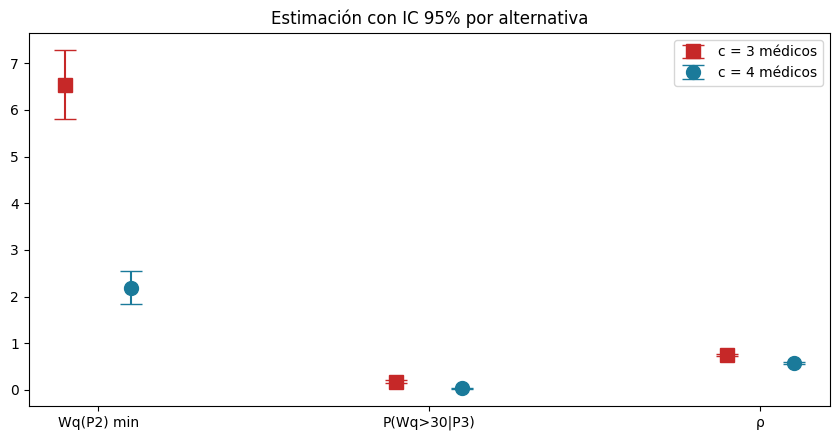

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
x = np.arange(len(metricas))
m3v = [res_3[:,i].mean() for i in range(3)]
m4v = [res_4[:,i].mean() for i in range(3)]
h3v = [t_cN*res_3[:,i].std(ddof=1)/np.sqrt(n_final) for i in range(3)]
h4v = [t_cN*res_4[:,i].std(ddof=1)/np.sqrt(n_final) for i in range(3)]

ax.errorbar(x-0.1, m3v, yerr=h3v, fmt='s', color='#C62828', capsize=8, markersize=10, label='c = 3 médicos')
ax.errorbar(x+0.1, m4v, yerr=h4v, fmt='o', color='#1A7A9A', capsize=8, markersize=10, label='c = 4 médicos')
ax.set_xticks(x); ax.set_xticklabels(metricas)
ax.set_title('Estimación con IC 95% por alternativa')
ax.legend()
plt.tight_layout(); plt.show()

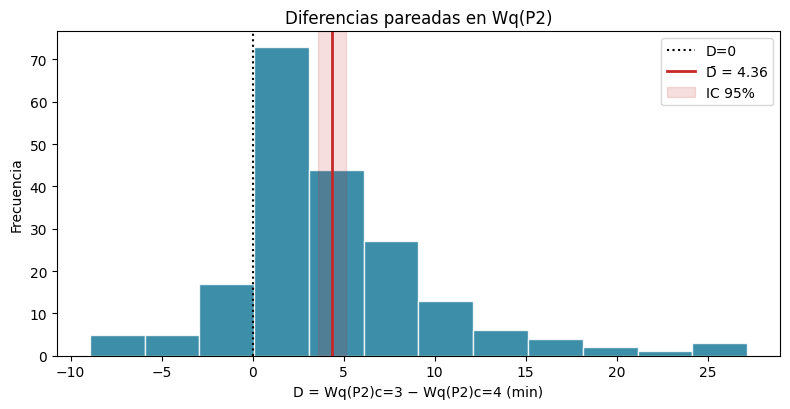

In [18]:
D_Wq = res_3[:, 0] - res_4[:, 0]
mD = D_Wq.mean()
hD = t_cN * D_Wq.std(ddof=1) / np.sqrt(n_final)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(D_Wq, bins=12, color='#1A7A9A', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=1.5, ls=':', label='D=0')
ax.axvline(mD, color='#C62828', lw=2, label=f'D̄ = {mD:.2f}')
ax.axvspan(mD-hD, mD+hD, alpha=0.15, color='#C62828', label='IC 95%')
ax.set_xlabel('D = Wq(P2)c=3 − Wq(P2)c=4 (min)'); ax.set_ylabel('Frecuencia')
ax.set_title('Diferencias pareadas en Wq(P2)')
ax.legend()
plt.tight_layout(); plt.show()

## Conclusiones

- Las observaciones **dentro** de una corrida están autocorrelacionadas → no usar S/√m.
- El método de **réplicas independientes** genera Y₁,...,Yₙ i.i.d. → estadística clásica (t-Student).
- El **procedimiento secuencial** determina cuántas réplicas se necesitan para una precisión deseada.
- La **prueba t pareada con CRN** decide entre alternativas con un IC mucho más estrecho que con réplicas independientes.
- Distribuciones con **menor CV** (Erlang vs. exponencial) producen estimadores más precisos con menos réplicas.
- Para sistemas complejos (urgencias con prioridades, servicios no exponenciales) la **simulación es la única herramienta**.
- Reportar siempre Ȳ con su IC y, si hay alternativas, el p-valor y el tamaño de efecto.

**Próximo tema:** T3.4 — simulaciones de estado estacionario: warm-up, Batch Means y CRN avanzado.